<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Послання на process_bank_churn.py: https://github.com/DiFedorchuk/ML_Course/blob/6b8131e2d1a4e7c6fd83222ed717cc17634e9bab/process_bank_churn.py

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from process_bank_churn import preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [4]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/train.csv")

In [5]:
data = preprocess_data(raw_df)

In [6]:
X_train = data['train_inputs']
y_train = data['train_targets']
X_val = data['val_inputs']
y_val = data['val_targets']

input_cols = data['input_cols']
scaler = data['scaler']
encoder = data['encoder']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (12000, 14)
y_train shape: (12000,)
X_val shape: (3000, 14)
y_val shape: (3000,)


In [7]:
# Видалимо колонку ID
if 'id' in X_train.columns:
    X_train = X_train.drop('id', axis=1)
    X_val = X_val.drop('id', axis=1)
    input_cols = [col for col in input_cols if col != 'id']
    print("Successfully removed 'id' column from X_train, X_val, and input_cols.")
else:
    print("'id' column not found in X_train.")

Successfully removed 'id' column from X_train, X_val, and input_cols.


In [8]:
# 1 Натренеруємо модель
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
# 2 Обчислимо ROC AUC
from sklearn.metrics import roc_auc_score
y_train_pred_proba = model.predict_proba(X_train)[:,1]
# ROC AUC для трейн
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)

y_val_pred_proba = model.predict_proba(X_val)[:, 1]
# ROC AUC для валідаційного
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
print(f"AUROC for training: {roc_auc_train:.4f}")
print(f"AUROC for validation: {roc_auc_val:.4f}")

AUROC for training: 1.0000
AUROC for validation: 0.7700


In [10]:
# 3 Глибина дерева
tree_depth = model.get_depth()
print(f"Depth of the tree: {tree_depth}")

Depth of the tree: 26


In [17]:
# 4 Побудуємо дерево до глибини 2 включно

In [11]:
from sklearn.tree import plot_tree, export_text

In [12]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- Age <= 0.38
|   |   |   |--- truncated branch of depth 24
|   |   |--- Age >  0.38
|   |   |   |--- truncated branch of depth 18
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 16
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 17
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- class: 1.0



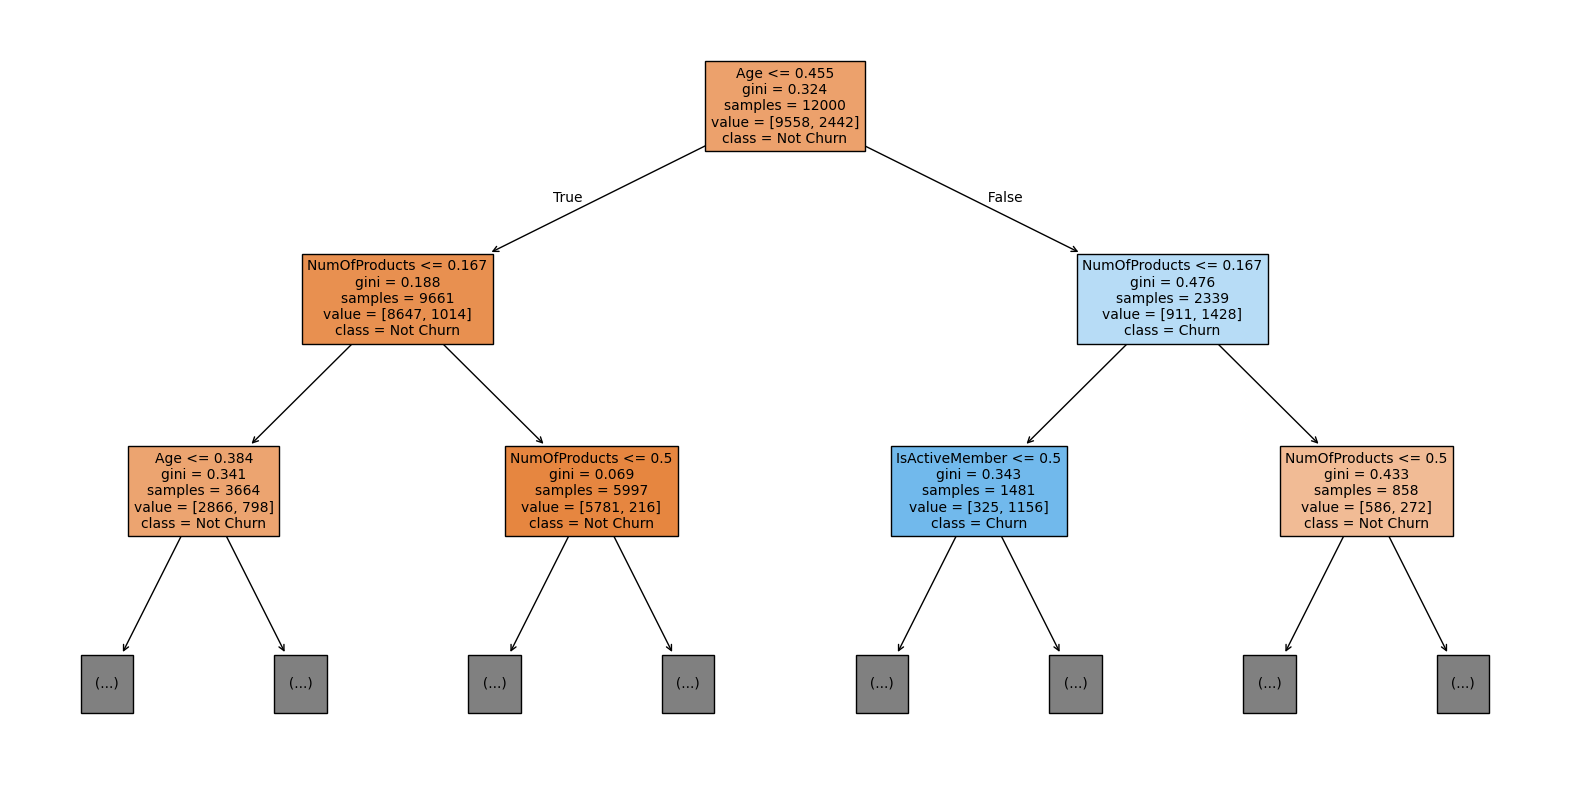

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(model, max_depth=2, feature_names=input_cols, filled=True, class_names=['Not Churn', 'Churn'], fontsize=10)
plt.show()


In [14]:
# 5 Важливість ознак
model.feature_importances_.round(2)

array([0.12, 0.36, 0.05, 0.08, 0.17, 0.01, 0.03, 0.12, 0.01, 0.01, 0.01,
       0.01, 0.01])

In [15]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [16]:
importance_df.head(10)

,feature,importance
1,Age,0.356789
4,NumOfProducts,0.168379
7,EstimatedSalary,0.123635
0,CreditScore,0.123283
3,Balance,0.079192
2,Tenure,0.052899
6,IsActiveMember,0.032688
11,Gender_Female,0.014908
9,Geography_Germany,0.014725
5,HasCrCard,0.012957


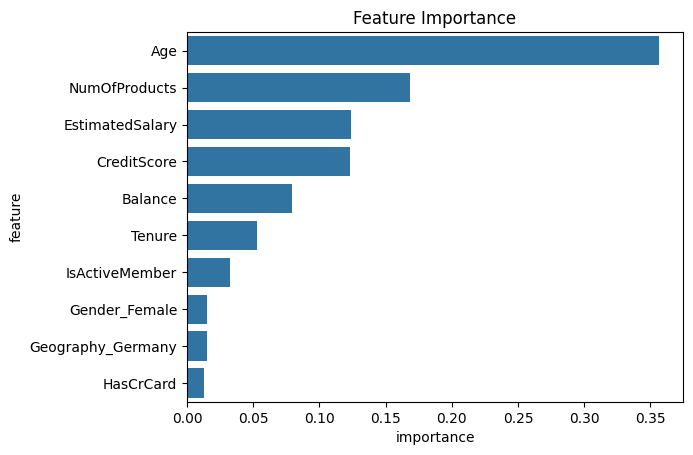

In [17]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [18]:
model = DecisionTreeClassifier(max_leaf_nodes = 22, max_depth = 10,random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=22, random_state=42)

In [19]:
y_train_pred_proba = model.predict_proba(X_train)[:,1]
# ROC AUC для трейн
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)

y_val_pred_proba = model.predict_proba(X_val)[:, 1]
# ROC AUC для валідаційного
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
print(f"AUROC for training: {roc_auc_train:.4f}")
print(f"AUROC for validation: {roc_auc_val:.4f}")

AUROC for training: 0.9190
AUROC for validation: 0.9188


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залежність між AUROC на трейн і валідаційних даних і номером ітерації.

Depth: 1, Train AUROC: 0.7447, Val AUROC: 0.7349
Depth: 2, Train AUROC: 0.8429, Val AUROC: 0.8465
Depth: 3, Train AUROC: 0.8972, Val AUROC: 0.8911
Depth: 4, Train AUROC: 0.9113, Val AUROC: 0.9113
Depth: 5, Train AUROC: 0.9257, Val AUROC: 0.9219
Depth: 6, Train AUROC: 0.9338, Val AUROC: 0.9211
Depth: 7, Train AUROC: 0.9415, Val AUROC: 0.9144
Depth: 8, Train AUROC: 0.9495, Val AUROC: 0.9031
Depth: 9, Train AUROC: 0.9591, Val AUROC: 0.8847
Depth: 10, Train AUROC: 0.9698, Val AUROC: 0.8484
Depth: 11, Train AUROC: 0.9780, Val AUROC: 0.8411
Depth: 12, Train AUROC: 0.9863, Val AUROC: 0.8249
Depth: 13, Train AUROC: 0.9920, Val AUROC: 0.8101
Depth: 14, Train AUROC: 0.9960, Val AUROC: 0.7948
Depth: 15, Train AUROC: 0.9983, Val AUROC: 0.7953
Depth: 16, Train AUROC: 0.9994, Val AUROC: 0.7812
Depth: 17, Train AUROC: 0.9998, Val AUROC: 0.7814
Depth: 18, Train AUROC: 0.9999, Val AUROC: 0.7830
Depth: 19, Train AUROC: 1.0000, Val AUROC: 0.7736
Depth: 20, Train AUROC: 1.0000, Val AUROC: 0.7753


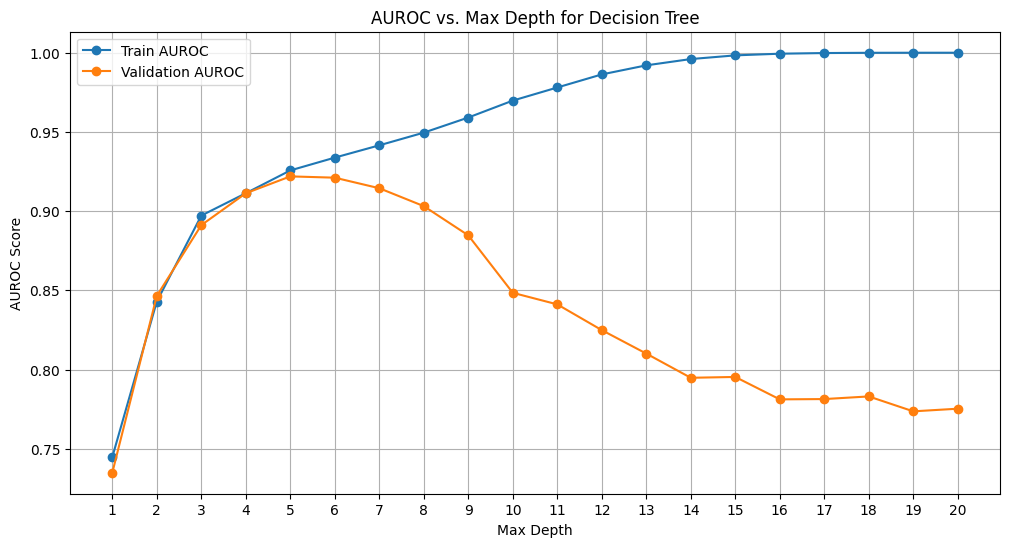

In [20]:
train_roc_auc_scores = []
val_roc_auc_scores = []
depth = range(1, 21)

for i in depth:
    model = DecisionTreeClassifier(max_depth=i, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
    train_roc_auc_scores.append(train_roc_auc)

    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
    val_roc_auc_scores.append(val_roc_auc)

    print(f"Depth: {i}, Train AUROC: {train_roc_auc:.4f}, Val AUROC: {val_roc_auc:.4f}")

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(depth, train_roc_auc_scores, label='Train AUROC', marker='o')
plt.plot(depth, val_roc_auc_scores, label='Validation AUROC', marker='o')
plt.title('AUROC vs. Max Depth for Decision Tree')
plt.xlabel('Max Depth')
plt.ylabel('AUROC Score')
plt.xticks(depth)
plt.grid(True)
plt.legend()
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [21]:
# 1 Найкраще значення max_depth є 5
model = DecisionTreeClassifier(max_depth = 5,random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [22]:
y_train_pred_proba = model.predict_proba(X_train)[:,1]
# ROC AUC для трейн
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)

y_val_pred_proba = model.predict_proba(X_val)[:, 1]
# ROC AUC для валідаційного
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
print(f"AUROC for training: {roc_auc_train:.4f}")
print(f"AUROC for validation: {roc_auc_val:.4f}")

AUROC for training: 0.9257
AUROC for validation: 0.9219


In [23]:
# 2. Завантажуємо новий файл
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/test.csv")

In [ ]:
# 3 Робимо обробку за допомогою функції preprocess_new_data

In [24]:
from process_bank_churn import preprocess_new_data

In [25]:
data = preprocess_new_data(raw_df, scaler=data['scaler'], encoder=data['encoder'])

In [29]:
# 4 Робимо передбачення на тестових даних
X_test = data['inputs']

# Видаляємо колонку id
if 'id' in X_test.columns:
    X_test = X_test.drop('id', axis=1)
    print("Successfully removed 'id' column from X_test.")
else:
    print("'id' column not found in X_test.")

test_predictions_proba = model.predict_proba(X_test)[:, 1]

Successfully removed 'id' column from X_test.


In [32]:
# 5 Записуємо результат в  submission.csv
submission_df = pd.DataFrame({'id': raw_df['id'], 'Exited': test_predictions_proba})
submission_df.to_csv('submission.csv', index=False)

print("Дані записано у файл")

Дані записано у файл


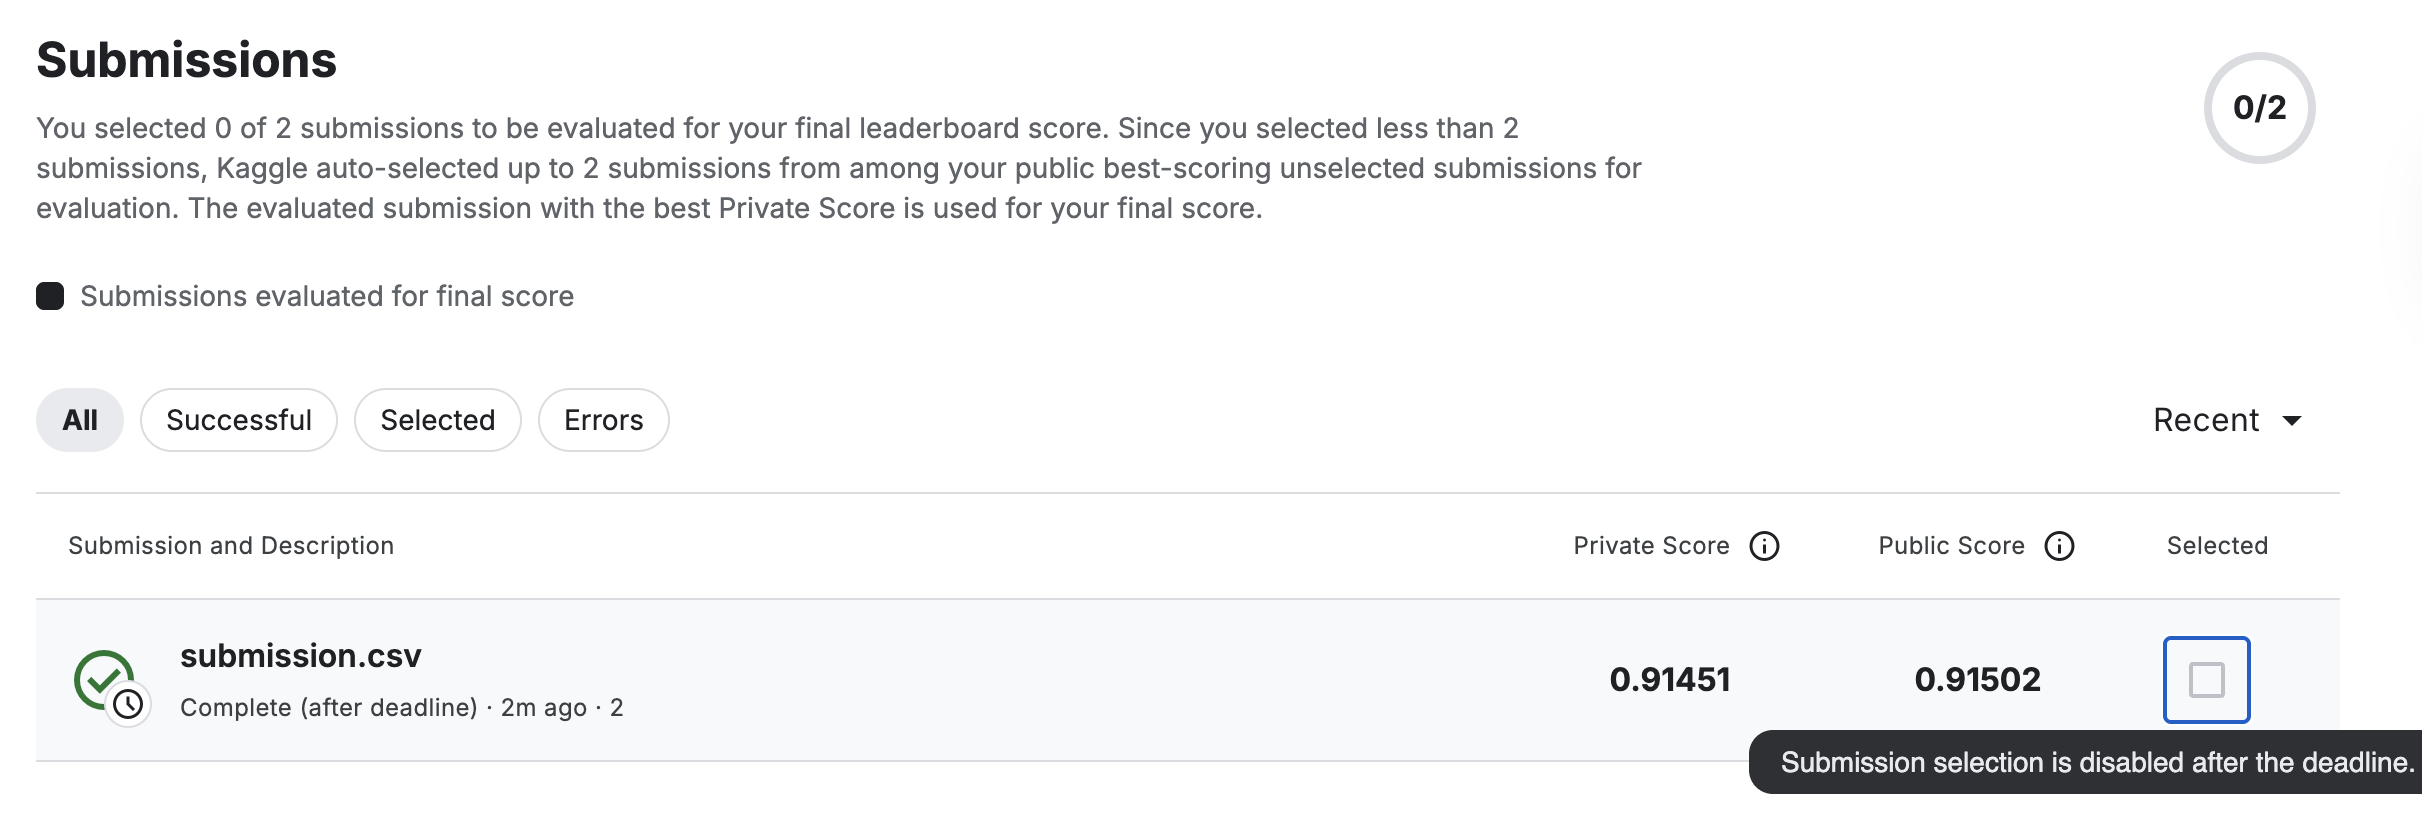